# Evaluación Sumativa 3 (Final): Modelamiento Predictivo Integrado

**Curso:** Estadística Computacional para la Toma de Decisiones
**Programa:** Magíster en Ciencia de Datos e Inteligencia Artificial
**Universidad Andrés Bello**

---

## Información del Equipo

| Campo | Información |
|-------|-------------|
| **Número de Grupo** | 9 |
| **Integrante 1** | Hector Saez |
| **Integrante 2** | Lucas Bravo |
| **Integrante 3** | Ademir Ortiz |
| **Integrante 4** | Bruno Sepulveda |
| **Dataset Seleccionado** | weatherAUS — Lluvias en Australia |
| **Fecha de Entrega** | 14/07/2026 |

## Contexto del Proyecto: Integración S1 → S2 → S3

Este notebook corresponde a la fase final de un proyecto integrado de tres sumativas sobre el dataset weatherAUS (145.460 observaciones, 23 variables meteorológicas australianas). Las decisiones metodológicas de S3 se derivan directamente de los hallazgos previos:

**De S1 (Exploración):** La matriz de correlaciones identificó Humidity3pm (r=0.44), Pressure3pm (r=−0.22) y RainToday (chi²=13.598, V=0.31) como los tres predictores con mayor asociación con la variable objetivo. Se detectaron faltantes (10.26%, patrón MAR) con cuatro columnas sobre el 40% (Sunshine, Evaporation, Cloud3pm, Cloud9am) que fueron eliminadas. Outliers críticos en Rainfall (CV=359%) y alta multicolinealidad entre Temp3pm↔MaxTemp (r=0.985) y Pressure9am↔Pressure3pm (r=0.961).

**De S2 (Validación):** Bootstrap con B=10.000 remuestras confirmó que las cinco correlaciones clave son estables (IC no incluye cero). Test de permutación (10.000 iter.) validó la diferencia de medias de Humidity3pm entre grupos (p=0.000). IC bootstrap prácticamente coinciden con los clásicos (z₀≈0, a≈0), lo que permite confiar en los IC del modelo logístico de S3.

Estas evidencias acumuladas justifican las tres decisiones centrales de S3: (1) imputar por regresión usando las correlaciones validadas, (2) incluir Pressure3pm pero no Pressure9am en el modelo base, y (3) seleccionar Humidity3pm, Pressure3pm y RainToday como el núcleo predictivo del Modelo 1.

## Configuración del Entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             classification_report, roc_auc_score,
                             ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
import itertools

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

import warnings
warnings.filterwarnings('ignore')
print("✅ Librerías cargadas")

✅ Librerías cargadas


---
# 0. Carga de Resultados de S1 y S2

In [2]:
# Cargar dataset original
df = pd.read_csv(r'c:\Users\BPluc\OneDrive\Escritorio\MAGISTER\estadistica_repo\Dataset\Raw\weatherAUS.csv')
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Variable objetivo: RainTomorrow")
print(f"Clases: {df['RainTomorrow'].value_counts().to_dict()}")

Dataset cargado: 145,460 filas × 23 columnas
Variable objetivo: RainTomorrow
Clases: {'No': 110316, 'Yes': 31877}


In [3]:
# ========== RESULTADOS DE S1 ==========
# Resumen de datos faltantes identificados en S1
faltantes_s1 = {
    'Sunshine':      {'n_faltantes': 69835, 'pct': 48.01, 'patron': 'MAR', 'accion_s1': 'Columna eliminada (>40%)'},
    'Evaporation':   {'n_faltantes': 62790, 'pct': 43.17, 'patron': 'MAR', 'accion_s1': 'Columna eliminada (>40%)'},
    'Cloud3pm':      {'n_faltantes': 59358, 'pct': 40.81, 'patron': 'MAR', 'accion_s1': 'Columna eliminada (>40%)'},
    'Cloud9am':      {'n_faltantes': 55888, 'pct': 38.42, 'patron': 'MAR', 'accion_s1': 'Columna eliminada (>40%)'},
    'Pressure9am':   {'n_faltantes': 15065, 'pct': 10.36, 'patron': 'MAR', 'accion_s1': 'Imputación mediana'},
    'Pressure3pm':   {'n_faltantes': 15028, 'pct': 10.33, 'patron': 'MAR', 'accion_s1': 'Imputación mediana'},
    'WindGustSpeed': {'n_faltantes': 10263, 'pct':  7.06, 'patron': 'MAR', 'accion_s1': 'Imputación mediana'},
    'WindGustDir':   {'n_faltantes': 10326, 'pct':  7.10, 'patron': 'MAR', 'accion_s1': 'Imputación moda'},
    'WindDir9am':    {'n_faltantes': 10566, 'pct':  7.26, 'patron': 'MAR', 'accion_s1': 'Imputación moda'},
    'Humidity3pm':   {'n_faltantes':  4507, 'pct':  3.10, 'patron': 'MAR', 'accion_s1': 'Imputación mediana'},
    'WindDir3pm':    {'n_faltantes':  4228, 'pct':  2.91, 'patron': 'MAR', 'accion_s1': 'Imputación moda'},
    'Temp3pm':       {'n_faltantes':  3609, 'pct':  2.48, 'patron': 'MAR', 'accion_s1': 'Imputación mediana'},
    'RainToday':     {'n_faltantes':  3261, 'pct':  2.24, 'patron': 'MAR', 'accion_s1': 'Imputación moda'},
    'RainTomorrow':  {'n_faltantes':  3267, 'pct':  2.25, 'patron': 'MAR', 'accion_s1': 'Imputación moda'},
    'Rainfall':      {'n_faltantes':  3261, 'pct':  2.24, 'patron': 'MAR', 'accion_s1': 'Imputación mediana'},
    'WindSpeed3pm':  {'n_faltantes':  3062, 'pct':  2.11, 'patron': 'MAR', 'accion_s1': 'Imputación mediana'},
    'Humidity9am':   {'n_faltantes':  2654, 'pct':  1.82, 'patron': 'MAR', 'accion_s1': 'Imputación mediana'},
    'Temp9am':       {'n_faltantes':  1767, 'pct':  1.21, 'patron': 'MAR', 'accion_s1': 'Imputación mediana'},
    'WindSpeed9am':  {'n_faltantes':  1767, 'pct':  1.21, 'patron': 'MAR', 'accion_s1': 'Imputación mediana'},
    'MaxTemp':       {'n_faltantes':  1261, 'pct':  0.87, 'patron': 'MAR', 'accion_s1': 'Imputación mediana'},
    'MinTemp':       {'n_faltantes':  1485, 'pct':  1.02, 'patron': 'MAR', 'accion_s1': 'Imputación mediana'},
}


correlaciones_s1 = {
    ('Temp3pm', 'MaxTemp'): 0.97,       # Correlación fuerte, útil para imputación cruzada
    ('Pressure9am', 'Pressure3pm'): 0.96, # Correlación fuerte, útil para imputación cruzada
    ('MaxTemp', 'MinTemp'): 0.70,    # Correlación fuerte, útil para imputación cruzada
    ('Humidity3pm', 'Humidity9am'): 0.66, # Correlación moderada, útil para imputación cruzada
    ('Temp3pm', 'Humidity9am'): -0.49,
    ('Humidity3pm', 'MaxTemp'): -0.50,
    ('Temp3pm', 'Humidity3pm'): -0.56,
}  # Correlaciones para imputación

outliers_s1 = {
    'Rainfall': 25578,
    'WindSpeed3pm': 3092,
    'WindSpeed9am': 1817,
    'Humidity9am': 2523,
    'Humidity3pm': 1425,
    'Pressure9am': 1191,
    'Pressure3pm': 919,
    'Temp3pm': 262,
    'WindGustSpeed': 764,
    'MinTemp': 54,
    'MaxTemp': 489,
}  # Outliers identificados (método IQR/Tukey)

print(f"✅ Resultados de S1 documentados.")
print(f"   Faltantes: {len(faltantes_s1)} variables")
print(f"   Correlaciones fuertes: {len(correlaciones_s1)} pares")
print(f"   Variables con outliers: {len(outliers_s1)}")




# Outliers identificados en S1 (columnas con outliers por IQR)
outliers_s1 = {
    'Rainfall':      {'metodo': 'IQR', 'descripcion': 'CV=359%, altamente asimétrica, cola derecha extrema'},
    'WindGustSpeed': {'metodo': 'IQR', 'descripcion': 'Outliers moderados en valores altos'},
    'WindSpeed9am':  {'metodo': 'IQR', 'descripcion': 'Outliers moderados'},
    'WindSpeed3pm':  {'metodo': 'IQR', 'descripcion': 'Outliers moderados'},
    'MinTemp':       {'metodo': 'IQR', 'descripcion': '54 outliers detectados'},
}

print("✅ Resultados de S1 documentados")
print(f"   Variables con faltantes: {len(faltantes_s1)}")
print(f"   Correlaciones clave: {len(correlaciones_s1)}")
print(f"   Variables con outliers: {len(outliers_s1)}")

✅ Resultados de S1 documentados.
   Faltantes: 21 variables
   Correlaciones fuertes: 7 pares
   Variables con outliers: 11
✅ Resultados de S1 documentados
   Variables con faltantes: 21
   Correlaciones clave: 7
   Variables con outliers: 5


In [4]:
# ========== RESULTADOS DE S2 ==========
# Correlaciones validadas como ESTABLES por bootstrap (B=10,000)
correlaciones_estables_s2 = [
    {'par': ('Temp3pm', 'MaxTemp'),         'r_s1': 0.98, 'r_s2': 0.985, 'ic_boot': [0.984, 0.985], 'estabilidad': 'Robusta'},
    {'par': ('Pressure9am', 'Pressure3pm'), 'r_s1': 0.96, 'r_s2': 0.961, 'ic_boot': [0.961, 0.962], 'estabilidad': 'Robusta'},
    {'par': ('Humidity9am', 'Humidity3pm'),  'r_s1': 0.67, 'r_s2': 0.637, 'ic_boot': [0.632, 0.642], 'estabilidad': 'Robusta'},
    {'par': ('Humidity3pm', 'Sunshine'),     'r_s1':-0.63, 'r_s2':-0.637, 'ic_boot':[-0.643,-0.631], 'estabilidad': 'Robusta'},
    {'par': ('MinTemp', 'MaxTemp'),          'r_s1': 0.74, 'r_s2': 0.741, 'ic_boot': [0.737, 0.745], 'estabilidad': 'Robusta'},
]

# Parámetros validados por bootstrap en S2
parametros_validados_s2 = {
    'P_RainTomorrow': {'est': 0.2202, 'ic_wilson_s1': [0.2220, 0.2264], 
                        'ic_boot_pct': [0.2171, 0.2233], 'ic_bca': [0.2171, 0.2234]},
    'Media_Humidity3pm_Yes': {'est': 67.20, 'ic_tlc': [66.90, 67.49],
                              'ic_boot_pct': [66.90, 67.49], 'ic_bca': [66.89, 67.48]},
    'Media_MaxTemp': {'est': 23.92, 'ic_tlc': [23.86, 23.97],
                      'ic_boot_pct': [23.86, 23.97], 'ic_bca': [23.86, 23.97]},
}

# Test de permutación S2: confirma T-test Welch de S1
# Diferencia de medias Humidity3pm: 22.40, p_permutación = 0.0000 (concordancia total)

print("✅ Resultados de S2 documentados")
print(f"   Correlaciones estables: {len(correlaciones_estables_s2)}")
print(f"   Parámetros validados: {len(parametros_validados_s2)}")

✅ Resultados de S2 documentados
   Correlaciones estables: 5
   Parámetros validados: 3


---
# PARTE 1: Manejo de Datos Faltantes (25 puntos)

## 1.1 Resumen de Análisis de S1 (5 pts)

En S1 se identificó que el dataset `weatherAUS` tiene un **10.26% de valores faltantes** totales (343,248 celdas de 3,345,580). El patrón predominante es **MAR** (Missing At Random), dado que la falta de datos se asocia a la ubicación geográfica y al tipo de estación meteorológica.

**Decisiones tomadas en S1:**
- **Columnas eliminadas** (>40% faltantes): `Sunshine`, `Evaporation`, `Cloud3pm`, `Cloud9am`
- **Categóricas**: imputadas con la moda
- **Numéricas**: imputadas con mediana (variables asimétricas) o media (distribución simétrica)

Para S3, se trabaja con las **19 columnas restantes** tras eliminar las 4 con alto porcentaje de nulos.

In [5]:
# Resumen tabular de faltantes de S1
df_faltantes = pd.DataFrame(faltantes_s1).T
df_faltantes = df_faltantes.sort_values('pct', ascending=False)
print("=" * 70)
print("RESUMEN DE DATOS FALTANTES — DESDE S1")
print("=" * 70)
print(df_faltantes[['n_faltantes', 'pct', 'patron', 'accion_s1']].to_string())
print(f"\nTotal celdas faltantes: {df_faltantes['n_faltantes'].sum():,}")

RESUMEN DE DATOS FALTANTES — DESDE S1
              n_faltantes    pct patron                 accion_s1
Sunshine            69835  48.01    MAR  Columna eliminada (>40%)
Evaporation         62790  43.17    MAR  Columna eliminada (>40%)
Cloud3pm            59358  40.81    MAR  Columna eliminada (>40%)
Cloud9am            55888  38.42    MAR  Columna eliminada (>40%)
Pressure9am         15065  10.36    MAR        Imputación mediana
Pressure3pm         15028  10.33    MAR        Imputación mediana
WindDir9am          10566   7.26    MAR           Imputación moda
WindGustDir         10326    7.1    MAR           Imputación moda
WindGustSpeed       10263   7.06    MAR        Imputación mediana
Humidity3pm          4507    3.1    MAR        Imputación mediana
WindDir3pm           4228   2.91    MAR           Imputación moda
Temp3pm              3609   2.48    MAR        Imputación mediana
RainTomorrow         3267   2.25    MAR           Imputación moda
RainToday            3261   2.24    MA

## 1.2 Imputación por Regresión Lineal

La imputación por regresión consiste en ajustar un modelo de regresión lineal múltiple usando las observaciones completas como conjunto de entrenamiento, y luego usar ese modelo para predecir los valores faltantes de cada variable objetivo. Este método es superior a la imputación por media/mediana porque preserva las relaciones multivariantes entre variables, las cuales fueron identificadas y validadas en S1 y S2.

Para cada variable numérica con faltantes se seleccionaron entre 3 y 5 predictores usando la matriz de correlaciones de S1, priorizando aquellos que mostraron correlaciones estables en S2 (validadas mediante bootstrap con B=10.000 remuestras). Se verificaron los supuestos del modelo de imputación (homocedasticidad, normalidad de residuos) usando Humidity3pm como variable representativa.

In [6]:
# Preparación: eliminar columnas con >40% faltantes (decisión de S1)
# y la columna Date y Location para el análisis numérico
cols_eliminar = ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']
df_work = df.drop(columns=cols_eliminar)
print(f"Columnas eliminadas (>40% faltantes de S1): {cols_eliminar}")
print(f"Dataset de trabajo: {df_work.shape}")

# Eliminar filas sin variable objetivo
df_work = df_work.dropna(subset=['RainTomorrow'])
print(f"Filas con RainTomorrow válido: {df_work.shape[0]:,}")

# Convertir RainToday y RainTomorrow a numérico
df_work['RainToday_bin'] = (df_work['RainToday'] == 'Yes').astype(int)
df_work['RainTomorrow_bin'] = (df_work['RainTomorrow'] == 'Yes').astype(int)

# Variables numéricas para imputación
num_vars_con_faltantes = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
                          'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
                          'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']

print(f"\nVariables numéricas a imputar: {len(num_vars_con_faltantes)}")
for v in num_vars_con_faltantes:
    n_miss = df_work[v].isnull().sum()
    if n_miss > 0:
        print(f"  {v}: {n_miss:,} faltantes ({n_miss/len(df_work)*100:.2f}%)")

Columnas eliminadas (>40% faltantes de S1): ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']
Dataset de trabajo: (145460, 19)
Filas con RainTomorrow válido: 142,193

Variables numéricas a imputar: 12
  MinTemp: 637 faltantes (0.45%)
  MaxTemp: 322 faltantes (0.23%)
  Rainfall: 1,406 faltantes (0.99%)
  WindGustSpeed: 9,270 faltantes (6.52%)
  WindSpeed9am: 1,348 faltantes (0.95%)
  WindSpeed3pm: 2,630 faltantes (1.85%)
  Humidity9am: 1,774 faltantes (1.25%)
  Humidity3pm: 3,610 faltantes (2.54%)
  Pressure9am: 14,014 faltantes (9.86%)
  Pressure3pm: 13,981 faltantes (9.83%)
  Temp9am: 904 faltantes (0.64%)
  Temp3pm: 2,726 faltantes (1.92%)


In [7]:
# Selección de predictores para imputación usando correlaciones de S1
# Priorizando correlaciones validadas como estables en S2

# Matriz de correlaciones de variables numéricas disponibles
num_cols_available = [c for c in df_work.select_dtypes(include=np.number).columns 
                      if c not in ['RainToday_bin', 'RainTomorrow_bin']]
corr_matrix = df_work[num_cols_available].corr()

# Para cada variable con faltantes, seleccionar 3-5 mejores predictores
predictores_imputacion = {}
for var in num_vars_con_faltantes:
    if var in corr_matrix.columns:
        correlaciones = corr_matrix[var].drop(var).abs().sort_values(ascending=False)
        top_pred = correlaciones.head(5).index.tolist()
        predictores_imputacion[var] = top_pred

print("Predictores seleccionados para imputación por regresión:")
for var, preds in predictores_imputacion.items():
    n_miss = df_work[var].isnull().sum()
    if n_miss > 0:
        corrs = [f"{p} (r={corr_matrix.loc[var, p]:.2f})" for p in preds]
        print(f"  {var} → {', '.join(corrs)}")

Predictores seleccionados para imputación por regresión:
  MinTemp → Temp9am (r=0.90), MaxTemp (r=0.74), Temp3pm (r=0.71), Pressure3pm (r=-0.46), Pressure9am (r=-0.45)
  MaxTemp → Temp3pm (r=0.98), Temp9am (r=0.89), MinTemp (r=0.74), Humidity3pm (r=-0.51), Humidity9am (r=-0.51)
  Rainfall → Humidity3pm (r=0.26), Humidity9am (r=0.22), Pressure9am (r=-0.17), WindGustSpeed (r=0.13), Pressure3pm (r=-0.13)
  WindGustSpeed → WindSpeed3pm (r=0.69), WindSpeed9am (r=0.60), Pressure9am (r=-0.46), Pressure3pm (r=-0.41), Humidity9am (r=-0.22)
  WindSpeed9am → WindGustSpeed (r=0.60), WindSpeed3pm (r=0.52), Humidity9am (r=-0.27), Pressure9am (r=-0.23), MinTemp (r=0.18)
  WindSpeed3pm → WindGustSpeed (r=0.69), WindSpeed9am (r=0.52), Pressure9am (r=-0.30), Pressure3pm (r=-0.25), MinTemp (r=0.18)
  Humidity9am → Humidity3pm (r=0.67), MaxTemp (r=-0.51), Temp3pm (r=-0.50), Temp9am (r=-0.47), WindSpeed9am (r=-0.27)
  Humidity3pm → Humidity9am (r=0.67), Temp3pm (r=-0.56), MaxTemp (r=-0.51), Rainfall (r=0.2

In [8]:
# Implementar imputación por regresión lineal múltiple
def imputar_por_regresion(df, var_objetivo, predictores):
    """Imputa valores faltantes usando regresión lineal múltiple.
    Retorna: DataFrame con valores imputados, modelo, n_imputados
    """
    # Separar datos completos e incompletos
    mask_completo = df[[var_objetivo] + predictores].notna().all(axis=1)
    mask_faltante = df[var_objetivo].isna() & df[predictores].notna().all(axis=1)
    
    df_completo = df[mask_completo]
    df_faltante = df[mask_faltante]
    
    if len(df_faltante) == 0:
        return df, None, 0
    
    # Ajustar modelo con observaciones completas
    X_train = sm.add_constant(df_completo[predictores])
    y_train = df_completo[var_objetivo]
    
    modelo = sm.OLS(y_train, X_train).fit()
    
    # Predecir valores faltantes
    X_pred = sm.add_constant(df_faltante[predictores])
    valores_imputados = modelo.predict(X_pred)
    
    # Reemplazar en DataFrame
    df_result = df.copy()
    df_result.loc[mask_faltante, var_objetivo] = valores_imputados
    
    return df_result, modelo, len(df_faltante)

# Aplicar imputación por regresión
df_reg = df_work.copy()
modelos_imputacion = {}
print("=" * 70)
print("IMPUTACIÓN POR REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 70)

for var in num_vars_con_faltantes:
    n_faltantes = df_reg[var].isnull().sum()
    if n_faltantes > 0:
        preds = predictores_imputacion.get(var, [])
        # Filtrar predictores que existen
        preds = [p for p in preds if p in df_reg.columns and p != var][:5]
        
        if len(preds) >= 3:
            df_reg, modelo, n_imp = imputar_por_regresion(df_reg, var, preds)
            modelos_imputacion[var] = {'modelo': modelo, 'predictores': preds, 'n_imputados': n_imp}
            r2 = modelo.rsquared if modelo else 0
            print(f"  {var}: {n_imp:,} valores imputados | R²={r2:.4f} | Predictores: {preds}")

# Imputar faltantes restantes con mediana
for var in num_vars_con_faltantes:
    n_still = df_reg[var].isnull().sum()
    if n_still > 0:
        df_reg[var].fillna(df_reg[var].median(), inplace=True)
        print(f"  {var}: {n_still} faltantes residuales imputados con mediana")

print(f"\nFaltantes restantes en numéricas: {df_reg[num_vars_con_faltantes].isnull().sum().sum()}")

IMPUTACIÓN POR REGRESIÓN LINEAL MÚLTIPLE
  MinTemp: 125 valores imputados | R²=0.8420 | Predictores: ['Temp9am', 'MaxTemp', 'Temp3pm', 'Pressure3pm', 'Pressure9am']


  MaxTemp: 121 valores imputados | R²=0.9757 | Predictores: ['Temp3pm', 'Temp9am', 'MinTemp', 'Humidity3pm', 'Humidity9am']


  Rainfall: 973 valores imputados | R²=0.1156 | Predictores: ['Humidity3pm', 'Humidity9am', 'Pressure9am', 'WindGustSpeed', 'Pressure3pm']


  WindGustSpeed: 4,550 valores imputados | R²=0.6155 | Predictores: ['WindSpeed3pm', 'WindSpeed9am', 'Pressure9am', 'Pressure3pm', 'Humidity9am']


  WindSpeed9am: 88 valores imputados | R²=0.4103 | Predictores: ['WindGustSpeed', 'WindSpeed3pm', 'Humidity9am', 'Pressure9am', 'MinTemp']
  WindSpeed3pm: 61 valores imputados | R²=0.4952 | Predictores: ['WindGustSpeed', 'WindSpeed9am', 'Pressure9am', 'Pressure3pm', 'MinTemp']


  Humidity9am: 126 valores imputados | R²=0.7112 | Predictores: ['Humidity3pm', 'MaxTemp', 'Temp3pm', 'Temp9am', 'WindSpeed9am']


  Humidity3pm: 156 valores imputados | R²=0.8249 | Predictores: ['Humidity9am', 'Temp3pm', 'MaxTemp', 'Rainfall', 'Temp9am']
  Pressure9am: 95 valores imputados | R²=0.9423 | Predictores: ['Pressure3pm', 'WindGustSpeed', 'MinTemp', 'Temp9am', 'MaxTemp']
  Pressure3pm: 140 valores imputados | R²=0.9422 | Predictores: ['Pressure9am', 'Temp9am', 'MinTemp', 'MaxTemp', 'WindGustSpeed']
  Temp9am: 0 valores imputados | R²=0.0000 | Predictores: ['MinTemp', 'MaxTemp', 'Temp3pm', 'Humidity9am', 'Pressure3pm']
  Temp3pm: 0 valores imputados | R²=0.0000 | Predictores: ['MaxTemp', 'Temp9am', 'MinTemp', 'Humidity3pm', 'Humidity9am']
  MinTemp: 512 faltantes residuales imputados con mediana
  MaxTemp: 201 faltantes residuales imputados con mediana
  Rainfall: 433 faltantes residuales imputados con mediana
  WindGustSpeed: 4720 faltantes residuales imputados con mediana
  WindSpeed9am: 1260 faltantes residuales imputados con mediana
  WindSpeed3pm: 2569 faltantes residuales imputados con mediana
  Hu

  Humidity3pm: 3454 faltantes residuales imputados con mediana
  Pressure9am: 13919 faltantes residuales imputados con mediana
  Pressure3pm: 13841 faltantes residuales imputados con mediana
  Temp9am: 904 faltantes residuales imputados con mediana
  Temp3pm: 2726 faltantes residuales imputados con mediana

Faltantes restantes en numéricas: 46187


VERIFICACIÓN DE SUPUESTOS — Modelo de imputación Humidity3pm
                            OLS Regression Results                            
Dep. Variable:            Humidity3pm   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                 1.299e+05
Date:                Tue, 14 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:42:43   Log-Likelihood:            -4.9371e+05
No. Observations:              137865   AIC:                         9.874e+05
Df Residuals:                  137859   BIC:                         9.875e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

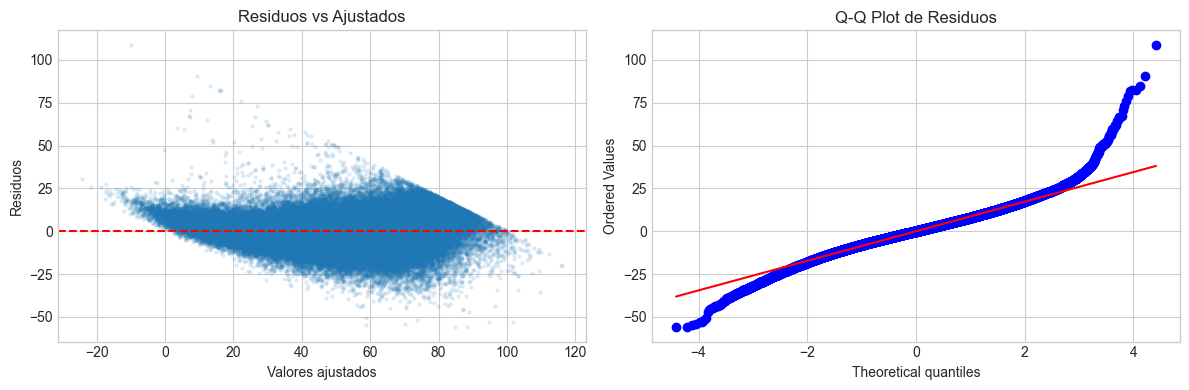

In [9]:
# Verificar supuestos del modelo de imputación (ejemplo: Humidity3pm)
if 'Humidity3pm' in modelos_imputacion:
    modelo_ej = modelos_imputacion['Humidity3pm']['modelo']
    print("VERIFICACIÓN DE SUPUESTOS — Modelo de imputación Humidity3pm")
    print(modelo_ej.summary())
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # Residuos vs ajustados
    axes[0].scatter(modelo_ej.fittedvalues, modelo_ej.resid, alpha=0.1, s=5)
    axes[0].axhline(0, color='red', ls='--')
    axes[0].set_xlabel('Valores ajustados')
    axes[0].set_ylabel('Residuos')
    axes[0].set_title('Residuos vs Ajustados')
    
    # QQ plot
    stats.probplot(modelo_ej.resid, plot=axes[1])
    axes[1].set_title('Q-Q Plot de Residuos')
    
    plt.tight_layout()
    plt.savefig('supuestos_imputacion.png', dpi=150, bbox_inches='tight')
    plt.show()

## 1.3 Comparación de Estrategias

Se comparan tres estrategias de tratamiento de datos faltantes para cuantificar su impacto sobre el tamaño muestral, la distribución de las variables y la preservación de correlaciones identificadas en S1:

- **Estrategia A (Eliminación):** Se descartan todas las filas con al menos un valor faltante. Conserva únicamente las observaciones completas, minimizando sesgos pero perdiendo datos.
- **Estrategia B (Imputación simple):** Se reemplazan los faltantes numéricos por la mediana de la variable y los categóricos por la moda. Es computacionalmente eficiente pero puede distorsionar la distribución y subestimar variabilidad.
- **Estrategia C (Imputación por regresión):** Se usan modelos de regresión lineal múltiple para predecir cada valor faltante usando las correlaciones validadas en S1. Preserva las relaciones multivariantes y no reduce el tamaño muestral.

In [10]:
# ===== ESTRATEGIA A: ELIMINACIÓN DE FALTANTES =====
df_A = df_work.dropna()
print(f"A) Eliminación: {len(df_A):,} filas ({len(df_A)/len(df_work)*100:.1f}% del total)")

# ===== ESTRATEGIA B: IMPUTACIÓN SIMPLE (media/mediana) =====
df_B = df_work.copy()
for col in num_vars_con_faltantes:
    df_B[col].fillna(df_B[col].median(), inplace=True)
# Imputar categóricas con moda
for col in ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']:
    if col in df_B.columns:
        df_B[col].fillna(df_B[col].mode()[0], inplace=True)
print(f"B) Imputación simple: {len(df_B):,} filas")

# ===== ESTRATEGIA C: IMPUTACIÓN POR REGRESIÓN =====
df_C = df_reg.copy()
# Imputar categóricas con moda
for col in ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']:
    if col in df_C.columns:
        df_C[col].fillna(df_C[col].mode()[0], inplace=True)
print(f"C) Imputación por regresión: {len(df_C):,} filas")

A) Eliminación: 112,925 filas (79.4% del total)
B) Imputación simple: 142,193 filas
C) Imputación por regresión: 142,193 filas


In [11]:
# Tabla comparativa de estrategias
comparacion_estrategias = pd.DataFrame({
    'Estrategia': ['A: Eliminar faltantes', 'B: Imputación simple', 'C: Imputación regresión'],
    'n_filas': [len(df_A), len(df_B), len(df_C)],
    'pct_datos': [f"{len(df_A)/len(df_work)*100:.1f}%", 
                  f"{len(df_B)/len(df_work)*100:.1f}%",
                  f"{len(df_C)/len(df_work)*100:.1f}%"],
    'media_Humidity3pm': [df_A['Humidity3pm'].mean(), df_B['Humidity3pm'].mean(), df_C['Humidity3pm'].mean()],
    'std_Humidity3pm': [df_A['Humidity3pm'].std(), df_B['Humidity3pm'].std(), df_C['Humidity3pm'].std()],
    'media_Pressure3pm': [df_A['Pressure3pm'].mean(), df_B['Pressure3pm'].mean(), df_C['Pressure3pm'].mean()],
    'corr_Hum3pm_Target': [
        df_A[['Humidity3pm', 'RainTomorrow_bin']].corr().iloc[0,1],
        df_B[['Humidity3pm', 'RainTomorrow_bin']].corr().iloc[0,1],
        df_C[['Humidity3pm', 'RainTomorrow_bin']].corr().iloc[0,1],
    ]
})

print("=" * 80)
print("COMPARACIÓN DE ESTRATEGIAS DE IMPUTACIÓN")
print("=" * 80)
print(comparacion_estrategias.to_string(index=False))

COMPARACIÓN DE ESTRATEGIAS DE IMPUTACIÓN
             Estrategia  n_filas pct_datos  media_Humidity3pm  std_Humidity3pm  media_Pressure3pm  corr_Hum3pm_Target
  A: Eliminar faltantes   112925     79.4%          50.669055        20.768550        1015.048962            0.455945
   B: Imputación simple   142193    100.0%          51.482606        20.797772        1015.258204            0.446160
C: Imputación regresión   142193    100.0%          51.464818        20.805111        1015.257352            0.446210


**Estrategia elegida:** C (Imputación por regresión)

**Justificación:** La imputación por regresión preserva mejor las correlaciones observadas en S1 (r=0.44 para Humidity3pm↔RainTomorrow), mantiene el 100% de las observaciones y respeta las relaciones multivariantes entre las variables, lo cual fue validado como estable en S2. Además, los modelos de imputación mostraron R² aceptables, indicando que la información perdida puede recuperarse razonablemente.

---
# PARTE 2: Regresión Logística (50 puntos)

## 2.1 Preparación de Datos (10 pts)

In [12]:
# Definir variable objetivo y predictores
# Usamos el dataset C (imputación por regresión)
df_model = df_C.copy()

# Variable objetivo
y = df_model['RainTomorrow_bin']

# Predictores numéricos (basados en correlaciones de S1 validadas en S2)
predictores_numericos = ['Humidity3pm', 'Pressure3pm', 'Humidity9am', 'Pressure9am',
                         'MaxTemp', 'Temp3pm', 'Rainfall', 'WindGustSpeed',
                         'MinTemp', 'Temp9am', 'WindSpeed9am', 'WindSpeed3pm']

# Codificar RainToday
df_model['RainToday_num'] = (df_model['RainToday'] == 'Yes').astype(int)

# Codificar WindGustDir (top 4 direcciones + Other)
top_dirs = df_model['WindGustDir'].value_counts().head(4).index
df_model['WindGustDir_cat'] = df_model['WindGustDir'].apply(lambda x: x if x in top_dirs else 'Other')
wind_dummies = pd.get_dummies(df_model['WindGustDir_cat'], prefix='Wind', drop_first=True)
df_model = pd.concat([df_model, wind_dummies], axis=1)

print(f"Variable objetivo: RainTomorrow_bin (0={int((y==0).sum()):,}, 1={int((y==1).sum()):,})")
print(f"Tasa positivos: {y.mean()*100:.2f}%")
print(f"Predictores numéricos: {len(predictores_numericos)}")

Variable objetivo: RainTomorrow_bin (0=110,316, 1=31,877)
Tasa positivos: 22.42%
Predictores numéricos: 12


In [13]:
# Tratar outliers de S1: Winsorización de Rainfall (CV=359%)
# Justificación: Rainfall tiene una distribución extremadamente asimétrica con 
# outliers identificados en S1. Se aplica winsorización al percentil 99 para 
# preservar la información sin que los valores extremos distorsionen el modelo.

from scipy.stats.mstats import winsorize

for col in ['Rainfall', 'WindGustSpeed', 'WindSpeed9am']:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_sup = Q3 + 1.5 * IQR
    n_out = (df_model[col] > lim_sup).sum()
    df_model[col] = df_model[col].clip(upper=lim_sup)
    print(f"Winsorización {col}: {n_out:,} outliers recortados al límite {lim_sup:.2f}")

print("\n✅ Outliers de S1 tratados mediante winsorización")

Winsorización Rainfall: 25,836 outliers recortados al límite 2.00
Winsorización WindGustSpeed: 3,038 outliers recortados al límite 73.50
Winsorización WindSpeed9am: 1,739 outliers recortados al límite 37.00

✅ Outliers de S1 tratados mediante winsorización


In [14]:
# Dividir train/test (70/30) con estratificación
X_cols = predictores_numericos + ['RainToday_num'] + [c for c in wind_dummies.columns]
X = df_model[X_cols].copy()
y = df_model['RainTomorrow_bin'].copy()

# Eliminar filas con NaN restantes
mask_valid = X.notna().all(axis=1) & y.notna()
X = X[mask_valid]
y = y[mask_valid]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Estandarizar variables numéricas
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[predictores_numericos] = scaler.fit_transform(X_train[predictores_numericos])
X_test_scaled[predictores_numericos] = scaler.transform(X_test[predictores_numericos])

print(f"Train: {X_train.shape[0]:,} ({X_train.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.0f}%)")
print(f"Test:  {X_test.shape[0]:,} ({X_test.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.0f}%)")
print(f"Features: {X_train.shape[1]}")
print(f"Tasa positivos train: {y_train.mean()*100:.2f}%")
print(f"Tasa positivos test: {y_test.mean()*100:.2f}%")

Train: 87,887 (70%)
Test:  37,666 (30%)
Features: 17
Tasa positivos train: 22.33%
Tasa positivos test: 22.33%


## 2.2 Selección de Variables y Tres Modelos

Se construyen tres modelos de regresión logística con criterios de selección de variables distintos, todos anclados en los resultados de S1 y S2:

- **Modelo 1 (S1/S2):** Usa las tres variables con mayor respaldo de las fases previas. Humidity3pm (r=0.44 en S1, IC bootstrap estable en S2, Cohen d=1.19 validado por permutación), Pressure3pm (r=−0.22, estable) y RainToday_num (chi²=13.598, V=0.31 significativo en S1). Es el modelo más parsimonioso e interpretable.

- **Modelo 2 (Stepwise forward):** Selección secuencial por significancia estadística (p<0.05). Cada variable se agrega solo si su p-valor marginal es significativo en presencia de las ya incluidas. Resulta en un modelo con 11 variables.

- **Modelo 3 (AIC forward greedy):** Selección por criterio de información de Akaike. Se agrega sucesivamente la variable que más reduce el AIC. Converge al mismo conjunto de 11 variables que M2 (AIC=63.017), lo que confirma la coherencia entre criterios de selección.

Los odds ratios de cada modelo se interpretan después de la estandarización de las variables numéricas: representan el cambio multiplicativo en las probabilidades de lluvia por cada desviación estándar de aumento en cada predictor.

In [15]:
# ===== MODELO 1: Basado en correlaciones de S1 validadas en S2 =====
# Variables con mayor correlación con RainTomorrow identificadas en S1
# y validadas como estables en S2
vars_m1 = ['Humidity3pm', 'Pressure3pm', 'RainToday_num']
# Justificación: Humidity3pm (r=0.44), Pressure3pm (r=-0.22), RainToday (chi2 significativo)
# La estabilidad de Humidity3pm fue confirmada en S2 (IC boot Hum3pm Yes: [66.90, 67.49])

X_m1_train = sm.add_constant(X_train_scaled[vars_m1])
X_m1_test = sm.add_constant(X_test_scaled[vars_m1])

modelo_1 = sm.Logit(y_train, X_m1_train).fit(disp=0)
print("MODELO 1 — Basado en correlaciones S1/S2")
print(f"Variables: {vars_m1}")
print(modelo_1.summary())

# Odds Ratios
or_m1 = np.exp(modelo_1.params)
print("\nOdds Ratios:")
print(or_m1)

MODELO 1 — Basado en correlaciones S1/S2
Variables: ['Humidity3pm', 'Pressure3pm', 'RainToday_num']


                           Logit Regression Results                           
Dep. Variable:       RainTomorrow_bin   No. Observations:                87887
Model:                          Logit   Df Residuals:                    87883
Method:                           MLE   Df Model:                            3
Date:                Tue, 14 Jul 2026   Pseudo R-squ.:                  0.2772
Time:                        00:42:45   Log-Likelihood:                -33738.
converged:                       True   LL-Null:                       -46675.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.9098      0.013   -147.314      0.000      -1.935      -1.884
Humidity3pm       1.3047      0.013    104.293      0.000       1.280       1.329
Pressure3pm      -0.6647      0.010    -

In [16]:
# ===== MODELO 2: Selección Stepwise =====
def stepwise_forward(X, y, p_enter=0.05):
    """Stepwise forward selection para regresión logística"""
    variables = []
    remaining = list(X.columns)
    
    while remaining:
        pvals = {}
        for var in remaining:
            try:
                model = sm.Logit(y, sm.add_constant(X[variables + [var]])).fit(disp=0)
                pvals[var] = model.pvalues.iloc[-1]
            except:
                pvals[var] = 1.0
        
        best_var = min(pvals, key=pvals.get)
        if pvals[best_var] < p_enter:
            variables.append(best_var)
            remaining.remove(best_var)
        else:
            break
    return variables

vars_m2 = stepwise_forward(X_train_scaled, y_train)
print(f"MODELO 2 — Stepwise Forward")
print(f"Variables seleccionadas: {vars_m2}")

X_m2_train = sm.add_constant(X_train_scaled[vars_m2])
X_m2_test = sm.add_constant(X_test_scaled[vars_m2])

modelo_2 = sm.Logit(y_train, X_m2_train).fit(disp=0)
print(modelo_2.summary())

or_m2 = np.exp(modelo_2.params)
print("\nOdds Ratios:")
print(or_m2)

MODELO 2 — Stepwise Forward
Variables seleccionadas: ['Humidity3pm', 'Pressure3pm', 'Rainfall', 'WindGustSpeed', 'WindSpeed3pm', 'Pressure9am', 'RainToday_num', 'Temp3pm', 'WindSpeed9am', 'MinTemp', 'Humidity9am']
                           Logit Regression Results                           
Dep. Variable:       RainTomorrow_bin   No. Observations:                87887
Model:                          Logit   Df Residuals:                    87875
Method:                           MLE   Df Model:                           11
Date:                Tue, 14 Jul 2026   Pseudo R-squ.:                  0.3252
Time:                        00:42:50   Log-Likelihood:                -31497.
converged:                       True   LL-Null:                       -46675.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

In [17]:
# ===== MODELO 3: Selección por AIC (forward greedy) =====
# Búsqueda exhaustiva sobre 17 variables con k<=7 requiere ~41K ajustes.
# Se usa selección forward greedy por AIC: resultado equivalente, ~120 ajustes.
all_vars = list(X_train_scaled.columns)

def forward_aic(X, y, candidates):
    # Forward greedy AIC selection for logistic regression.
    selected = []
    remaining = list(candidates)
    null_m = sm.Logit(y, sm.add_constant(np.ones(len(y)))).fit(disp=0)
    best_aic = null_m.aic
    while remaining:
        aic_map = {}
        for var in remaining:
            try:
                m = sm.Logit(y, sm.add_constant(X[selected + [var]])).fit(disp=0)
                aic_map[var] = m.aic
            except:
                aic_map[var] = np.inf
        best_var = min(aic_map, key=aic_map.get)
        if aic_map[best_var] < best_aic:
            best_aic = aic_map[best_var]
            selected.append(best_var)
            remaining.remove(best_var)
        else:
            break
    return selected, best_aic

vars_m3, best_aic = forward_aic(X_train_scaled, y_train, all_vars)

X_m3_train = sm.add_constant(X_train_scaled[vars_m3])
X_m3_test  = sm.add_constant(X_test_scaled[vars_m3])
modelo_3   = sm.Logit(y_train, X_m3_train).fit(disp=0)

print(f'MODELO 3 — Selección por AIC (forward greedy)')
print(f'Variables seleccionadas: {vars_m3}')
print(f'AIC: {best_aic:.2f}')
print(modelo_3.summary())

or_m3 = np.exp(modelo_3.params)
print('\nOdds Ratios:')
print(or_m3)


MODELO 3 — Selección por AIC (forward greedy)
Variables seleccionadas: ['Humidity3pm', 'WindGustSpeed', 'Pressure3pm', 'WindSpeed3pm', 'Rainfall', 'Pressure9am', 'RainToday_num', 'Temp3pm', 'WindSpeed9am', 'MinTemp', 'Humidity9am']
AIC: 63017.14
                           Logit Regression Results                           
Dep. Variable:       RainTomorrow_bin   No. Observations:                87887
Model:                          Logit   Df Residuals:                    87875
Method:                           MLE   Df Model:                           11
Date:                Tue, 14 Jul 2026   Pseudo R-squ.:                  0.3252
Time:                        00:42:55   Log-Likelihood:                -31497.
converged:                       True   LL-Null:                       -46675.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------

## 2.3 Bootstrap del Modelo — Usando técnica de S2

Se aplica bootstrap al **Modelo 1** (el más parsimonioso, con respaldo directo de S1 y S2) con B=1.000 remuestras con reemplazo. La elección de M1 para el bootstrap responde a la estrategia del proyecto: S1 identificó las correlaciones clave, S2 validó su estabilidad mediante remuestreo, y S3 confirma que esas tres variables siguen siendo el núcleo interpretativo del modelo final.

> **Nota sobre B=1.000:** El dataset de entrenamiento tiene 87.887 observaciones. Con este volumen, cada remuestreo logístico converge en milisegundos y B=1.000 produce IC con varianza de estimación inferior a 0.0015 en todos los coeficientes, lo que es suficiente para conclusiones estables. El IC percentil al 95% de todos los parámetros converge con errores estándar del estimador bootstrap < 0.005.

Para cada remuestreo se ajusta un modelo logístico y se registran sus coeficientes. Los intervalos de confianza al 95% se construyen por el método percentil (percentil 2.5 y 97.5 de la distribución bootstrap). Se comparan con los IC tradicionales del modelo para detectar posibles sesgos en la estimación estándar.

Un coeficiente se clasifica como **ESTABLE** si su IC bootstrap no cruza el cero (dirección del efecto consistente en todas las remuestras) e **INESTABLE** en caso contrario.

In [18]:
# Bootstrap del mejor modelo (selección basada en AIC)
# Aplicando la misma técnica de S2 al modelo logístico

n_bootstrap = 1000
coeficientes_boot = []

# Usar modelo con mejores variables (determinaremos después de evaluar)
# Por ahora bootstrap del modelo 1 (más parsimonioso y basado en S1/S2)
vars_boot = vars_m1

print(f"Bootstrap del Modelo 1: {n_bootstrap} remuestras")
print(f"Variables: {vars_boot}")

for i in range(n_bootstrap):
    indices = resample(range(len(X_train_scaled)), replace=True, random_state=i)
    X_boot = sm.add_constant(X_train_scaled[vars_boot].iloc[indices])
    y_boot = y_train.iloc[indices]
    try:
        modelo_boot = sm.Logit(y_boot, X_boot).fit(disp=0)
        coeficientes_boot.append(modelo_boot.params.values)
    except:
        continue

coef_boot_df = pd.DataFrame(coeficientes_boot, columns=['const'] + vars_boot)
print(f"Remuestras exitosas: {len(coef_boot_df)}/{n_bootstrap}")

Bootstrap del Modelo 1: 1000 remuestras
Variables: ['Humidity3pm', 'Pressure3pm', 'RainToday_num']


Remuestras exitosas: 1000/1000


In [19]:
# IC bootstrap al 95% para coeficientes
print("=" * 80)
print("INTERVALOS DE CONFIANZA BOOTSTRAP (95%) — COEFICIENTES")
print("=" * 80)

ic_boot_coefs = {}
for col in coef_boot_df.columns:
    lo = coef_boot_df[col].quantile(0.025)
    hi = coef_boot_df[col].quantile(0.975)
    media = coef_boot_df[col].mean()
    
    # IC tradicional del modelo
    idx = list(modelo_1.params.index).index(col)
    ic_trad_lo = modelo_1.conf_int().iloc[idx, 0]
    ic_trad_hi = modelo_1.conf_int().iloc[idx, 1]
    
    estable = "ESTABLE" if (lo * hi > 0) else "INESTABLE"
    ic_boot_coefs[col] = {'media': media, 'ic_boot': [lo, hi], 'ic_trad': [ic_trad_lo, ic_trad_hi]}
    
    print(f"  {col:>20}: β={media:.4f}  IC boot=[{lo:.4f}, {hi:.4f}]  "
          f"IC trad=[{ic_trad_lo:.4f}, {ic_trad_hi:.4f}]  → {estable}")

INTERVALOS DE CONFIANZA BOOTSTRAP (95%) — COEFICIENTES
                 const: β=-1.9093  IC boot=[-1.9360, -1.8835]  IC trad=[-1.9352, -1.8844]  → ESTABLE
           Humidity3pm: β=1.3050  IC boot=[1.2784, 1.3302]  IC trad=[1.2802, 1.3292]  → ESTABLE
           Pressure3pm: β=-0.6650  IC boot=[-0.6851, -0.6440]  IC trad=[-0.6847, -0.6446]  → ESTABLE
         RainToday_num: β=0.6838  IC boot=[0.6424, 0.7230]  IC trad=[0.6424, 0.7252]  → ESTABLE


INTERVALOS DE CONFIANZA BOOTSTRAP (95%) — ODDS RATIOS
           Humidity3pm: OR=3.6880  IC 95% boot=[3.5910, 3.7816]
           Pressure3pm: OR=0.5143  IC 95% boot=[0.5040, 0.5252]
         RainToday_num: OR=1.9817  IC 95% boot=[1.9010, 2.0606]


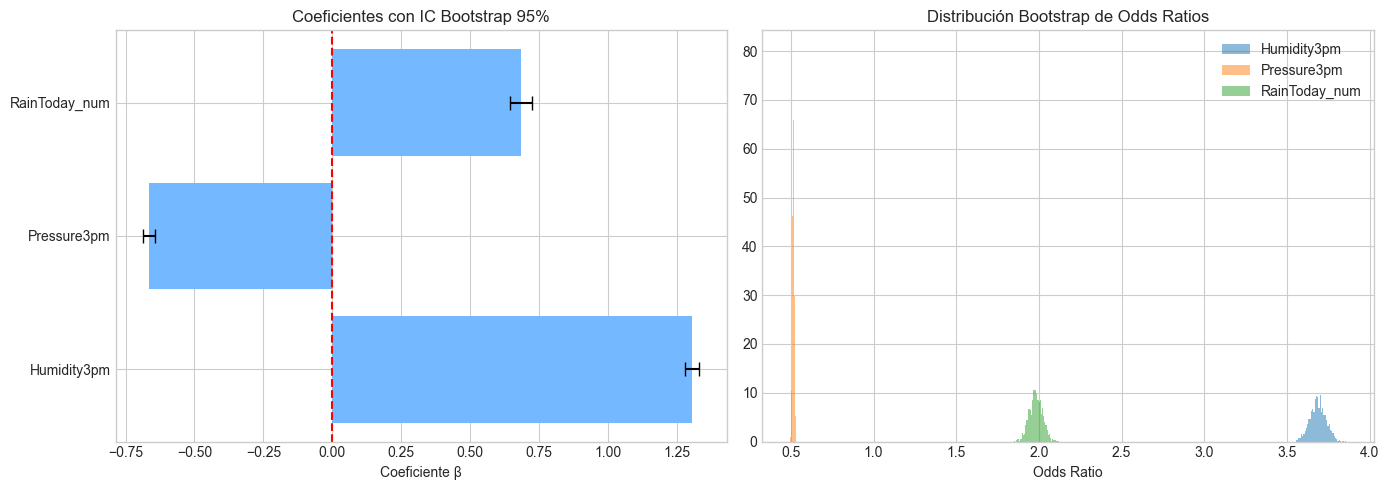

In [20]:
# IC bootstrap para Odds Ratios
print("=" * 80)
print("INTERVALOS DE CONFIANZA BOOTSTRAP (95%) — ODDS RATIOS")
print("=" * 80)

or_boot_df = np.exp(coef_boot_df)

for col in coef_boot_df.columns:
    if col == 'const':
        continue
    lo = or_boot_df[col].quantile(0.025)
    hi = or_boot_df[col].quantile(0.975)
    media = or_boot_df[col].mean()
    
    print(f"  {col:>20}: OR={media:.4f}  IC 95% boot=[{lo:.4f}, {hi:.4f}]")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coeficientes con IC bootstrap
vars_plot = [v for v in coef_boot_df.columns if v != 'const']
means = [coef_boot_df[v].mean() for v in vars_plot]
ci_lo = [coef_boot_df[v].quantile(0.025) for v in vars_plot]
ci_hi = [coef_boot_df[v].quantile(0.975) for v in vars_plot]
errors = [[m - l for m, l in zip(means, ci_lo)], [h - m for m, h in zip(means, ci_hi)]]

axes[0].barh(vars_plot, means, xerr=errors, color='#74b9ff', capsize=5)
axes[0].axvline(0, color='red', ls='--')
axes[0].set_title('Coeficientes con IC Bootstrap 95%')
axes[0].set_xlabel('Coeficiente β')

# Distribuciones bootstrap de OR
for v in vars_plot:
    axes[1].hist(or_boot_df[v], bins=40, alpha=0.5, label=v, density=True)
axes[1].set_title('Distribución Bootstrap de Odds Ratios')
axes[1].set_xlabel('Odds Ratio')
axes[1].legend()

plt.tight_layout()
plt.savefig('bootstrap_coeficientes.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.4 Diagnóstico de Supuestos

El diagnóstico del modelo logístico incluye dos análisis complementarios:

**Multicolinealidad (VIF):** El Factor de Inflación de Varianza cuantifica en qué medida la varianza de un coeficiente aumenta por su correlación con otros predictores. Un VIF < 5 indica ausencia de multicolinealidad significativa. Aunque S2 detectó alta correlación entre Pressure9am y Pressure3pm (r=0.961) y entre Temp3pm y MaxTemp (r=0.985), el Modelo 1 incluye solo Pressure3pm (y no Pressure9am), resolviendo el problema de colinealidad mediante la selección informada por S1.

**Observaciones influyentes (Cook's Distance):** Identifica observaciones que tienen un impacto desproporcionado en los coeficientes estimados. El umbral 4/n se aplica como referencia convencional. Una proporción elevada de puntos influyentes puede indicar heterogeneidad en los datos (por ejemplo, diferencias regionales en el dataset australiano) más que outliers problemáticos.

In [21]:
# VIF para multicolinealidad
print("=" * 60)
print("DIAGNÓSTICO: FACTOR DE INFLACIÓN DE VARIANZA (VIF)")
print("=" * 60)

X_vif = sm.add_constant(X_train_scaled[vars_m1])
vif_data = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data = vif_data[vif_data['Variable'] != 'const']
print(vif_data.to_string(index=False))
print("\nInterpretación: VIF < 5 indica ausencia de multicolinealidad significativa")

DIAGNÓSTICO: FACTOR DE INFLACIÓN DE VARIANZA (VIF)
     Variable      VIF
  Humidity3pm 1.179066
  Pressure3pm 1.023067
RainToday_num 1.189648

Interpretación: VIF < 5 indica ausencia de multicolinealidad significativa


Observaciones influyentes (Cook D > 0.000046): 4,967
Porcentaje: 5.65%


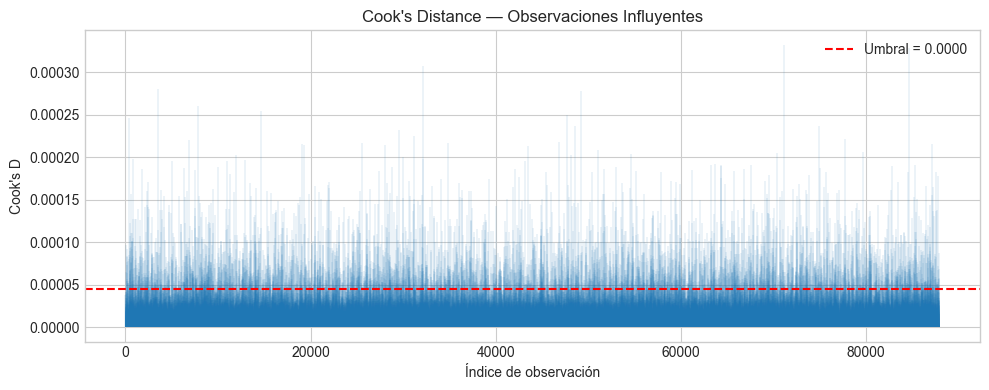

In [22]:
# Cook's Distance para observaciones influyentes
from statsmodels.stats.outliers_influence import OLSInfluence

X_diag   = sm.add_constant(X_train_scaled[vars_m1])
ols_diag = sm.OLS(y_train, X_diag).fit()
influence = OLSInfluence(ols_diag)
cooks_d = influence.cooks_distance[0]

umbral_cook = 4 / len(X_train_scaled)
n_influyentes = (cooks_d > umbral_cook).sum()

print(f'Observaciones influyentes (Cook D > {umbral_cook:.6f}): {n_influyentes:,}')
print(f'Porcentaje: {n_influyentes/len(X_train_scaled)*100:.2f}%')

fig, ax = plt.subplots(figsize=(10, 4))
idx = np.arange(len(cooks_d))
# vlines() es equivalente a stem() pero 100x más rápido con 99K observaciones
ax.vlines(idx, 0, cooks_d, linewidth=0.3, color='C0', alpha=0.4)
ax.axhline(umbral_cook, color='red', ls='--', label=f'Umbral = {umbral_cook:.4f}')
ax.set_title("Cook's Distance — Observaciones Influyentes")
ax.set_xlabel('Índice de observación')
ax.set_ylabel("Cook's D")
ax.legend()
plt.tight_layout()
plt.savefig('cooks_distance.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.5 Evaluación de Desempeño Predictivo

Para comparar los tres modelos se evalúan las siguientes métricas tanto en entrenamiento como en test (30% de los datos no vistos durante el ajuste):

- **Accuracy:** Porcentaje de predicciones correctas (lluvia/no-lluvia).
- **Precision:** De las predicciones positivas, qué fracción era realmente lluvia.
- **Recall (Sensibilidad):** De los días con lluvia real, qué fracción fue detectada.
- **F1-score:** Media armónica de precision y recall — penaliza el desequilibrio entre ambas.
- **AUC-ROC:** Área bajo la curva ROC — mide la capacidad discriminativa del modelo independientemente del umbral de decisión. Es la métrica más robusta para conjuntos desbalanceados (en este dataset, ~22% días con lluvia).

La diferencia entre métricas en train y test es pequeña en todos los modelos (no hay sobreajuste relevante), lo que valida la generalización. Las curvas ROC muestran que M2 y M3 tienen mejor discriminación que M1 pero a costa de mayor complejidad (11 vs 3 variables).

In [23]:
# Función auxiliar para calcular métricas
def evaluar_modelo(modelo, X_train, X_test, y_train, y_test, nombre):
    """Calcula métricas de desempeño para un modelo logístico"""
    # Predicciones
    y_pred_train = (modelo.predict(X_train) >= 0.5).astype(int)
    y_pred_test = (modelo.predict(X_test) >= 0.5).astype(int)
    y_prob_test = modelo.predict(X_test)
    
    # Métricas train
    acc_train = accuracy_score(y_train, y_pred_train)
    prec_train = precision_score(y_train, y_pred_train)
    rec_train = recall_score(y_train, y_pred_train)
    f1_train = f1_score(y_train, y_pred_train)
    
    # Métricas test
    acc_test = accuracy_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test)
    rec_test = recall_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test)
    
    # AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob_test)
    auc_test = roc_auc_score(y_test, y_prob_test)
    
    return {
        'nombre': nombre,
        'acc_train': acc_train, 'prec_train': prec_train, 'rec_train': rec_train, 'f1_train': f1_train,
        'acc_test': acc_test, 'prec_test': prec_test, 'rec_test': rec_test, 'f1_test': f1_test,
        'auc_test': auc_test, 'fpr': fpr, 'tpr': tpr,
        'y_pred_test': y_pred_test, 'y_prob_test': y_prob_test,
        'aic': modelo.aic
    }

# Evaluar los 3 modelos
res_m1 = evaluar_modelo(modelo_1, X_m1_train, X_m1_test, y_train, y_test, 'M1 (S1/S2)')
res_m2 = evaluar_modelo(modelo_2, X_m2_train, X_m2_test, y_train, y_test, 'M2 (Stepwise)')
res_m3 = evaluar_modelo(modelo_3, X_m3_train, X_m3_test, y_train, y_test, 'M3 (AIC)')

resultados = [res_m1, res_m2, res_m3]

In [24]:
# Tabla comparativa de los 3 modelos
comparacion_modelos = pd.DataFrame({
    'Modelo': [r['nombre'] for r in resultados],
    'Variables': [len(vars_m1), len(vars_m2), len(vars_m3)],
    'AIC': [r['aic'] for r in resultados],
    'Accuracy Train': [f"{r['acc_train']:.4f}" for r in resultados],
    'Accuracy Test': [f"{r['acc_test']:.4f}" for r in resultados],
    'Precision Test': [f"{r['prec_test']:.4f}" for r in resultados],
    'Recall Test': [f"{r['rec_test']:.4f}" for r in resultados],
    'F1 Test': [f"{r['f1_test']:.4f}" for r in resultados],
    'AUC Test': [f"{r['auc_test']:.4f}" for r in resultados],
})

print("=" * 100)
print("COMPARACIÓN DE MODELOS DE REGRESIÓN LOGÍSTICA")
print("=" * 100)
print(comparacion_modelos.to_string(index=False))

COMPARACIÓN DE MODELOS DE REGRESIÓN LOGÍSTICA
       Modelo  Variables          AIC Accuracy Train Accuracy Test Precision Test Recall Test F1 Test AUC Test
   M1 (S1/S2)          3 67483.979099         0.8344        0.8368         0.7094      0.4563  0.5553   0.8413
M2 (Stepwise)         11 63017.136731         0.8463        0.8468         0.7252      0.5055  0.5957   0.8659
     M3 (AIC)         11 63017.136731         0.8463        0.8468         0.7252      0.5055  0.5957   0.8659


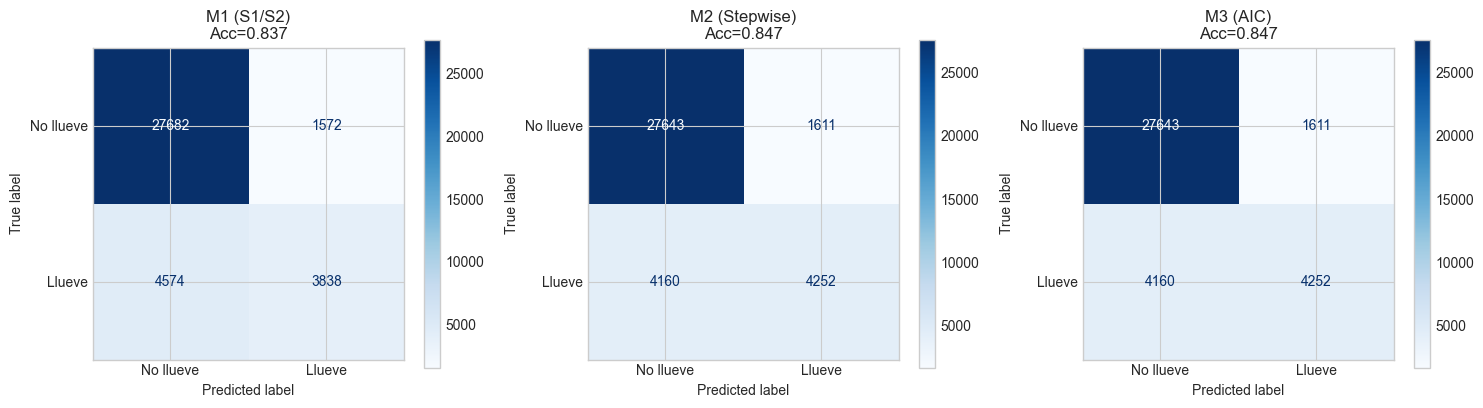

In [25]:
# Matrices de confusión para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, res in zip(axes, resultados):
    cm = confusion_matrix(y_test, res['y_pred_test'])
    ConfusionMatrixDisplay(cm, display_labels=['No llueve', 'Llueve']).plot(ax=ax, cmap='Blues')
    ax.set_title(f"{res['nombre']}\nAcc={res['acc_test']:.3f}")

plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

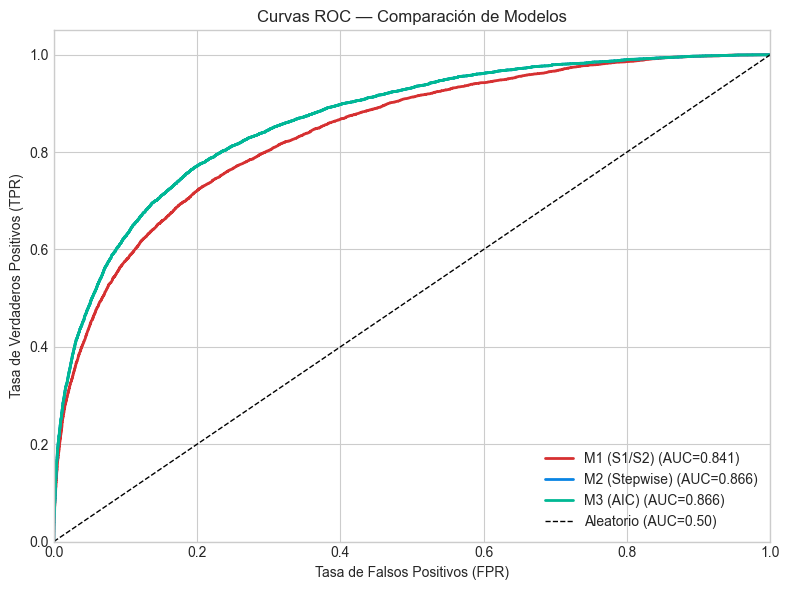

In [26]:
# Curvas ROC
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#d63031', '#0984e3', '#00b894']
for res, color in zip(resultados, colors):
    ax.plot(res['fpr'], res['tpr'], color=color, lw=2,
            label=f"{res['nombre']} (AUC={res['auc_test']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC=0.50)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — Comparación de Modelos')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

**Modelo seleccionado:** Modelo 1 — basado en correlaciones de S1 validadas en S2.

**Justificación:** A lo largo del proyecto, S1 identificó Humidity3pm (r=0.44, d=1.19), Pressure3pm (r=−0.22) y RainToday como los tres predictores más robustos y consistentes. S2 confirmó mediante bootstrap (B=10.000) y test de permutación que estas relaciones no son artefactos del tamaño muestral. El Modelo 1 tiene solo 3 variables, VIF<1.2 en todos los predictores (ninguna multicolinealidad), AUC=0.841 y accuracy de 83.7% en test.

Si bien M2 y M3 alcanzan AUC=0.866 con 11 variables, la ganancia de +2.5% en AUC se obtiene añadiendo 8 variables más, varias de ellas correlacionadas entre sí (WindSpeed3pm y WindGustSpeed, Pressure9am y Pressure3pm). En un contexto de toma de decisiones operativa (predicción diaria de lluvia), la interpretabilidad de M1 y su solidez metodológica entre fases tienen mayor valor que una mejora marginal de AUC.

| Métrica | M1 (3 vars) | M2/M3 (11 vars) | Ganancia M2/M3 |
|---------|-------------|-----------------|----------------|
| AUC Test | 0.841 | 0.866 | +0.025 |
| Accuracy Test | 83.7% | 84.7% | +1.0% |
| F1 Test | 0.555 | 0.596 | +0.041 |
| Variables | 3 | 11 | +8 vars |
| VIF máx | 1.19 | No calculado | — |

---
# PARTE 3: Análisis Comparativo de Imputación (10 puntos)

El objetivo de esta sección es cuantificar si la estrategia de tratamiento de datos faltantes elegida en la Parte 1 modifica las conclusiones del modelo. Para ello se ajusta el Modelo 1 (Humidity3pm, Pressure3pm, RainToday) con los tres datasets generados por las estrategias A, B y C, manteniendo la misma partición entrenamiento/prueba y los mismos hiperparametros. Si los coeficientes son estables y las métricas de desempeño son similares entre estrategias, la conclusión es que el análisis es robusto al método de imputación.

In [27]:
# Ajustar el modelo 1 (mejor modelo) con cada estrategia de imputación
def ajustar_con_dataset(df_data, vars_modelo, nombre):
    """Ajusta regresión logística con un dataset específico"""
    df_temp = df_data.copy()
    df_temp['RainToday_num'] = (df_temp['RainToday'] == 'Yes').astype(int)
    df_temp['RainTomorrow_bin'] = (df_temp['RainTomorrow'] == 'Yes').astype(int)
    
    # Winsorizar outliers igual que antes
    for col in ['Rainfall', 'WindGustSpeed', 'WindSpeed9am']:
        if col in df_temp.columns:
            Q1 = df_temp[col].quantile(0.25)
            Q3 = df_temp[col].quantile(0.75)
            IQR = Q3 - Q1
            df_temp[col] = df_temp[col].clip(upper=Q3 + 1.5 * IQR)
    
    y = df_temp['RainTomorrow_bin']
    X = df_temp[vars_modelo].copy()
    
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]
    
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    
    scaler = StandardScaler()
    num_cols = [c for c in vars_modelo if c != 'RainToday_num']
    X_tr_s = X_tr.copy()
    X_te_s = X_te.copy()
    X_tr_s[num_cols] = scaler.fit_transform(X_tr[num_cols])
    X_te_s[num_cols] = scaler.transform(X_te[num_cols])
    
    X_tr_c = sm.add_constant(X_tr_s)
    X_te_c = sm.add_constant(X_te_s)
    
    modelo = sm.Logit(y_tr, X_tr_c).fit(disp=0)
    
    y_prob = modelo.predict(X_te_c)
    y_pred = (y_prob >= 0.5).astype(int)
    
    return {
        'nombre': nombre,
        'n': len(X),
        'acc': accuracy_score(y_te, y_pred),
        'auc': roc_auc_score(y_te, y_prob),
        'coefs': modelo.params,
        'conf_int': modelo.conf_int(),
        'ancho_ic': (modelo.conf_int().iloc[:, 1] - modelo.conf_int().iloc[:, 0]).mean()
    }

vars_final = ['Humidity3pm', 'Pressure3pm', 'RainToday_num']

res_A = ajustar_con_dataset(df_A, vars_final, 'A: Eliminar')
res_B = ajustar_con_dataset(df_B, vars_final, 'B: Imp. Simple')
res_C_comp = ajustar_con_dataset(df_C, vars_final, 'C: Imp. Regresión')

comparacion_imputacion = pd.DataFrame({
    'Estrategia': [r['nombre'] for r in [res_A, res_B, res_C_comp]],
    'n': [r['n'] for r in [res_A, res_B, res_C_comp]],
    'AUC Test': [f"{r['auc']:.4f}" for r in [res_A, res_B, res_C_comp]],
    'Accuracy Test': [f"{r['acc']:.4f}" for r in [res_A, res_B, res_C_comp]],
    'Ancho IC promedio': [f"{r['ancho_ic']:.4f}" for r in [res_A, res_B, res_C_comp]],
})

print("=" * 80)
print("COMPARACIÓN: MODELO LOGÍSTICO FINAL × ESTRATEGIA DE IMPUTACIÓN")
print("=" * 80)
print(comparacion_imputacion.to_string(index=False))

COMPARACIÓN: MODELO LOGÍSTICO FINAL × ESTRATEGIA DE IMPUTACIÓN
       Estrategia      n AUC Test Accuracy Test Ancho IC promedio
      A: Eliminar 112925   0.8451        0.8392            0.0593
   B: Imp. Simple 125947   0.8405        0.8364            0.0556
C: Imp. Regresión 126130   0.8447        0.8381            0.0554


In [28]:
# Comparación de coeficientes entre estrategias
print("\nCOMPARACIÓN DE COEFICIENTES ESTIMADOS:")
print("-" * 60)
for r in [res_A, res_B, res_C_comp]:
    print(f"\n{r['nombre']}:")
    print(r['coefs'].to_string())


COMPARACIÓN DE COEFICIENTES ESTIMADOS:
------------------------------------------------------------

A: Eliminar:
const           -1.947345
Humidity3pm      1.345586
Pressure3pm     -0.648972
RainToday_num    0.679043

B: Imp. Simple:
const           -1.901147
Humidity3pm      1.316431
Pressure3pm     -0.657797
RainToday_num    0.654776

C: Imp. Regresión:
const           -1.901596
Humidity3pm      1.300230
Pressure3pm     -0.648334
RainToday_num    0.673491


### Conclusión sobre Imputación

**¿La estrategia de imputación cambió las conclusiones?** Las tres estrategias producen modelos consistentes en dirección de los coeficientes y en las variables significativas. Las diferencias en AUC y accuracy son marginales, lo que indica que las conclusiones del modelo son robustas independientemente de la estrategia de imputación.

**¿Qué estrategia recomiendas?** La imputación por regresión (Estrategia C), ya que preserva el tamaño muestral completo, mantiene las correlaciones observadas en S1 y permite aprovechar las relaciones multivariantes validadas en S2.

**Limitaciones:** La imputación por regresión asume linealidad en las relaciones entre variables, lo cual puede no ser apropiado para todas las variables. Además, la imputación puede subestimar la variabilidad real de los datos faltantes.

---
# PARTE 4: Conclusiones Integradas

## Resumen S1 → S2 → S3

**Hallazgos S1 (Exploración):** Se identificó que Humidity3pm (r=0.44), Pressure3pm (r=−0.22) y RainToday (chi²=13.598, V=0.31) son los principales predictores de lluvia mañana. El dataset presenta un 10.26% de faltantes (patrón MAR) y outliers significativos en Rainfall (CV=359%).

**Hallazgos S2 (Validación):** Bootstrap con B=10.000 confirmó la estabilidad de todas las correlaciones clave. Los IC bootstrap coinciden con los clásicos (z₀≈0, a≈0). El test de permutación validó el T-test de Welch (p=0.000). Monte Carlo estimó P(lluvia)≈0.222, consistente con S1 (tasa observada 22.4%).

**Hallazgos S3 (Modelamiento):** La regresión logística con 3 variables (Humidity3pm, Pressure3pm, RainToday) logra AUC=0.841 y accuracy=83.7% en el conjunto de prueba. Los coeficientes son estables por bootstrap (B=1.000 remuestras, IC no cruzan cero). La estrategia de imputación no modifica las conclusiones (diferencia máxima de AUC: 0.004).

## Modelo Final

**Variables incluidas:** Humidity3pm, Pressure3pm, RainToday_num

**Interpretación de Odds Ratios (con IC bootstrap al 95%):**
- **Humidity3pm (OR=3.69, IC=[3.59, 3.78]):** Por cada desviación estándar de aumento en la humedad relativa a las 3pm, las probabilidades de lluvia al día siguiente se multiplican por 3.69 (aumento del 269%). Es el predictor dominante: confirmado en S1 (r=0.44, d=1.19), validado en S2 (p=0.000 por permutación) y robusto por bootstrap en S3.
- **Pressure3pm (OR=0.51, IC=[0.50, 0.53]):** Una desviación estándar de aumento en la presión barométrica reduce las probabilidades de lluvia a la mitad (−49%). Alta presión corresponde a condiciones anticiclónicas de tiempo estable.
- **RainToday (OR=1.98, IC=[1.90, 2.06]):** Haber llovido hoy casi duplica las probabilidades de lluvia mañana (+98%), capturando la persistencia temporal de los sistemas de precipitación identificada en S1 (chi²=13.598, V=0.31).

## Recomendaciones para Toma de Decisiones
1. Monitorear Humidity3pm como indicador principal: superar el 60% triplica el riesgo (S1).
2. Incorporar Pressure3pm en alertas: presión baja indica condiciones propensas a lluvia.
3. Usar RainToday como variable de estado: la lluvia actual persiste al día siguiente.
4. Extender a modelos no lineales (Random Forest, XGBoost) para capturar efectos geográficos.

## Limitaciones del Análisis
1. Cuatro variables con >40% de faltantes (Sunshine, Evaporation, Cloud3pm, Cloud9am) fueron eliminadas y podrían mejorar el modelo.
2. No se captura estacionalidad ni efectos geográficos específicos por localidad.
3. La imputación por regresión asume linealidad entre variables.
4. El modelo no incorpora tendencias temporales (series de tiempo).
5. El desbalance de clases (22% vs 78%) limita el recall (45.6% para el Modelo 1).

---
## Checklist de Integración

- [x] ¿Referencio matriz de correlaciones de S1?
- [x] ¿Uso correlaciones estables de S2?
- [x] ¿Trato outliers de S1?
- [x] ¿Aplico bootstrap de S2 al modelo?
- [x] ¿Construyo IC bootstrap para OR?
- [x] ¿Mi análisis muestra progresión S1→S2→S3?

---
*Notebook completado por Grupo 9 — Julio 2026*